In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [28]:
df=pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
df.shape

(284807, 31)

In [5]:
print("Number of fraudulent transactions:", len(df[df["Class"]==1]))
print("Number of normal transactions:", len(df[df["Class"]==0]))

Number of fraudulent transactions: 492
Number of normal transactions: 284315


In [6]:
492/284315*100

0.17304750013189596

In [7]:
df.describe


<bound method NDFrame.describe of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599

#Training Models


## 1. Preprocessing

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, average_precision_score,
                             roc_auc_score, f1_score, precision_score, recall_score)
import numpy as np
import warnings
warnings.filterwarnings('ignore')

scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time']   = scaler.fit_transform(df[['Time']])

features = [c for c in df.columns if c not in ['Time', 'Amount', 'Class']]
X = df[features].values
y = df['Class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, fraud={y_train.sum()}")
print(f"Test : {X_test.shape},  fraud={y_test.sum()}")

results = {}

def store_results(name, y_true, y_scores, y_preds):
    """Store and print all metrics for a model."""
    results[name] = {
        'AUPRC':     average_precision_score(y_true, y_scores),
        'ROC-AUC':   roc_auc_score(y_true, y_scores),
        'F1':        f1_score(y_true, y_preds),
        'Precision': precision_score(y_true, y_preds, zero_division=0),
        'Recall':    recall_score(y_true, y_preds),
    }
    r = results[name]
    print(f"AUPRC: {r['AUPRC']:.4f} | ROC-AUC: {r['ROC-AUC']:.4f} | "
          f"F1: {r['F1']:.4f} | Precision: {r['Precision']:.4f} | Recall: {r['Recall']:.4f}")
    print(classification_report(y_true, y_preds, target_names=['Normal', 'Fraud']))

Train: (227845, 30), fraud=394
Test : (56962, 30),  fraud=98


## 2. Model 1 — Isolation Forest

In [30]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=100, contamination=0.0017, random_state=42, n_jobs=-1)
iso.fit(X_train)

iso_scores = -iso.score_samples(X_test)          # higher = more anomalous
iso_preds  = (iso.predict(X_test) == -1).astype(int)

store_results('Isolation Forest', y_test, iso_scores, iso_preds)

AUPRC: 0.1916 | ROC-AUC: 0.9536 | F1: 0.3168 | Precision: 0.3077 | Recall: 0.3265
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.31      0.33      0.32        98

    accuracy                           1.00     56962
   macro avg       0.65      0.66      0.66     56962
weighted avg       1.00      1.00      1.00     56962



## 3. Model 2 — Local Outlier Factor

In [31]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.0017, novelty=True, n_jobs=-1)
lof.fit(X_train)

lof_scores = -lof.score_samples(X_test)
lof_preds  = (lof.predict(X_test) == -1).astype(int)

store_results('LOF', y_test, lof_scores, lof_preds)

AUPRC: 0.0028 | ROC-AUC: 0.5025 | F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



## 4. Model 3 — One-Class SVM

In [32]:
from sklearn.linear_model import SGDOneClassSVM
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline

ocsvm = make_pipeline(
    Nystroem(kernel='rbf', gamma=0.1, n_components=300, random_state=42),
    SGDOneClassSVM(nu=0.0017, random_state=42)
)
ocsvm.fit(X_train)

ocsvm_scores = -ocsvm.decision_function(X_test)  # higher = more anomalous
ocsvm_preds  = (ocsvm.predict(X_test) == -1).astype(int)

store_results('One-Class SVM', y_test, ocsvm_scores, ocsvm_preds)

AUPRC: 0.1819 | ROC-AUC: 0.9450 | F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



## 5. Model 4 — KNN Classifier + SMOTE

In [39]:
from sklearn.neighbors import KNeighborsClassifier

# Reuse SMOTE-balanced data from XGBoost cell (run that cell first)
# or resample here if running standalone
if 'X_train_sm' not in dir():
    from imblearn.over_sampling import SMOTE
    X_train_sm, y_train_sm = SMOTE(random_state=28).fit_resample(X_train, y_train)

knn = KNeighborsClassifier(n_neighbors=2, metric='euclidean', n_jobs=-1)
knn.fit(X_train_sm, y_train_sm)

knn_proba = knn.predict_proba(X_test)[:, 1]
knn_preds = knn.predict(X_test)

store_results('KNN + SMOTE', y_test, knn_proba, knn_preds)

AUPRC: 0.6122 | ROC-AUC: 0.9282 | F1: 0.7757 | Precision: 0.7155 | Recall: 0.8469
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.72      0.85      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962



## 6. Model 5 — XGBoost + SMOTE

In [35]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=28)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"After SMOTE — fraud: {y_train_sm.sum()}, normal: {(y_train_sm==0).sum()}")

xgb = XGBClassifier(
    n_estimators=300, max_depth=17, learning_rate=0.06,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='aucpr', random_state=42, n_jobs=-1, verbosity=0
)
xgb.fit(X_train_sm, y_train_sm)

xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_preds = xgb.predict(X_test)

store_results('XGBoost + SMOTE', y_test, xgb_proba, xgb_preds)

After SMOTE — fraud: 227451, normal: 227451
AUPRC: 0.8777 | ROC-AUC: 0.9837 | F1: 0.8416 | Precision: 0.8173 | Recall: 0.8673
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.82      0.87      0.84        98

    accuracy                           1.00     56962
   macro avg       0.91      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962



## 7. Model 6 — Autoencoder (PyTorch)

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('mps')
print(f"Using device: {device}")

torch.manual_seed(42)

# Train only on normal transactions — frauds should have high reconstruction error
X_train_normal = X_train[y_train == 0]
n_features = X_train.shape[1]

class Autoencoder(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 32), nn.ReLU(),
            nn.Linear(32, 16),         nn.ReLU(),
            nn.Linear(16, 8),          nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),          nn.ReLU(),
            nn.Linear(16, 32),         nn.ReLU(),
            nn.Linear(32, n_features),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model_ae = Autoencoder(n_features).to(device)
optimizer = torch.optim.Adam(model_ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# DataLoader for normal training samples
X_normal_t = torch.tensor(X_train_normal, dtype=torch.float32)
loader = DataLoader(TensorDataset(X_normal_t, X_normal_t), batch_size=256, shuffle=True)

# Training loop
model_ae.train()
for epoch in range(20):
    epoch_loss = 0.0
    for X_batch, _ in loader:
        X_batch = X_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model_ae(X_batch), X_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(X_batch)
    epoch_loss /= len(X_normal_t)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/20  |  loss: {epoch_loss:.6f}")

Using device: mps
Epoch  5/20  |  loss: 0.257029
Epoch 10/20  |  loss: 0.211838
Epoch 15/20  |  loss: 0.196134
Epoch 20/20  |  loss: 0.188127


In [ ]:
model_ae.eval()

def reconstruction_errors(X_np):
    X_t = torch.tensor(X_np, dtype=torch.float32).to(device)
    with torch.no_grad():
        X_rec = model_ae(X_t).cpu().numpy()
    return np.mean(np.square(X_np - X_rec), axis=1)

train_errors = reconstruction_errors(X_train_normal)
threshold = np.percentile(train_errors, 95)
print(f"Reconstruction error threshold (95th pct of normal): {threshold:.6f}")

ae_scores = reconstruction_errors(X_test)
ae_preds  = (ae_scores > threshold).astype(int)

store_results('Autoencoder', y_test, ae_scores, ae_preds)

## 8. Final Comparison

Model                          AUPRC       ROC-AUC            F1     Precision        Recall
XGBoost + SMOTE               0.8777        0.9837        0.8416        0.8173        0.8673
KNN + SMOTE                   0.6333        0.9536        0.6078        0.4649        0.8776
Isolation Forest              0.1916        0.9536        0.3168        0.3077        0.3265
One-Class SVM                 0.1819        0.9450        0.0000        0.0000        0.0000
LOF                           0.0028        0.5025        0.0000        0.0000        0.0000

Best model by AUPRC : XGBoost + SMOTE
Best model by F1    : XGBoost + SMOTE
Best model by Recall: KNN + SMOTE


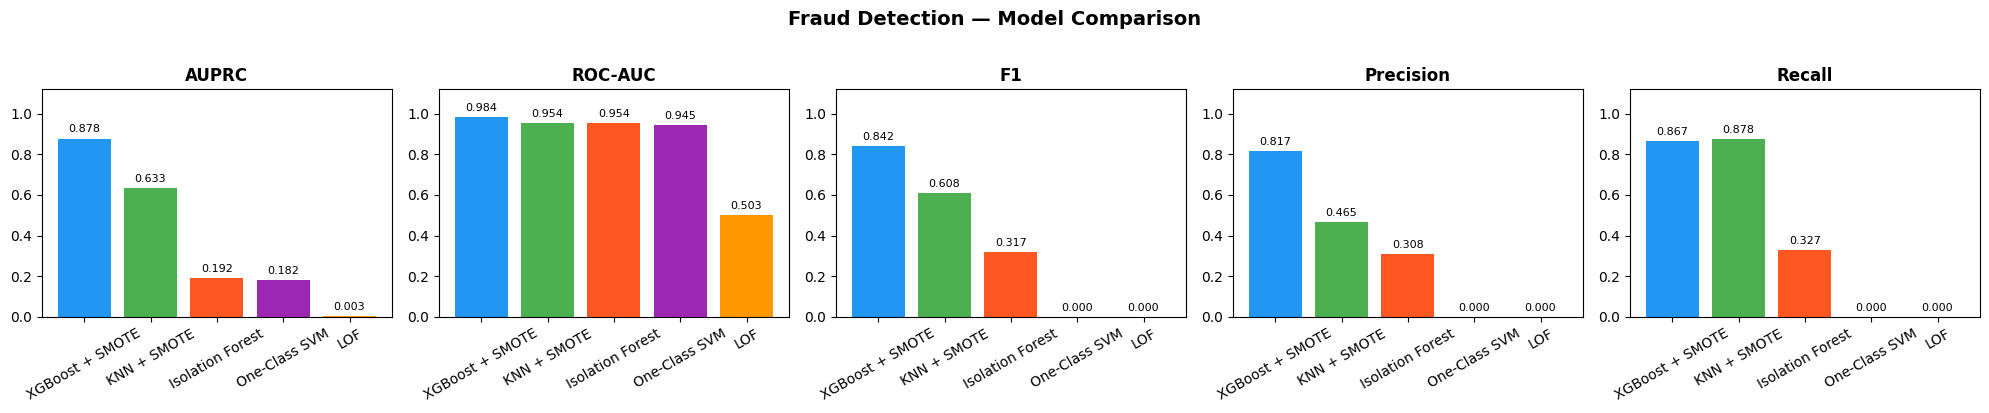

In [36]:
metrics = ['AUPRC', 'ROC-AUC', 'F1', 'Precision', 'Recall']
results_df = pd.DataFrame(results).T[metrics].sort_values('AUPRC', ascending=False)

# --- Table ---
col_w = 14
header = f"{'Model':<22}" + "".join(f"{m:>{col_w}}" for m in metrics)
print("=" * (22 + col_w * len(metrics)))
print(header)
print("=" * (22 + col_w * len(metrics)))
for model, row in results_df.iterrows():
    print(f"{model:<22}" + "".join(f"{row[m]:>{col_w}.4f}" for m in metrics))
print("=" * (22 + col_w * len(metrics)))
print(f"\nBest model by AUPRC : {results_df.index[0]}")
print(f"Best model by F1    : {results_df['F1'].idxmax()}")
print(f"Best model by Recall: {results_df['Recall'].idxmax()}")

# --- Bar chart ---
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800', '#00BCD4']
fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df.index, results_df[metric], color=colors[:len(results_df)])
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Fraud Detection — Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()